In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw2-task2.ipynb")

# Homework 2 - Task 2: Classification 
## Predicting High Asthma Prevalence : Do Social and Economic Conditions Predict Whether a Community Has Elevated Asthma Risk?

---

### Background

The **CDC/ATSDR Environmental Justice Index (EJI)** measures the cumulative environmental and social burdens faced by communities across the United States at the census-tract level. It combines three modules:

- **Environmental Burden Module (EBM)**: air quality, proximity to hazardous waste sites, impaired water bodies
- **Social Vulnerability Module (SVM)**: poverty, unemployment, race/ethnicity, housing conditions, health insurance
- **Health Vulnerability Module (HVM)**: prevalence of asthma, cancer, diabetes, mental illness

Research consistently shows that communities with greater poverty, unemployment, and minority populations bear a disproportionate share of environmental health burdens — including elevated rates of asthma. But can we actually predict which census tracts are in the top tier of asthma prevalence using only social vulnerability indicators?

**Your goal** is to build and compare two binary classification models — **K-Nearest Neighbors (KNN)** and **Logistic Regression** — that predict whether a census tract falls in the **top third** of asthma prevalence nationally. You will use **5-fold cross-validation** to select the best KNN hyperparameter and compare the results of both models. 

---

### Download the data
Follow these instructions to obtain the data for this assignment: 
1. Navigate to [this link](https://www.atsdr.cdc.gov/place-health/php/eji/eji-data-download.html)
1. Select the 2024 dropdown for the United States. 
2. **Choose the CSV File Type, and then click "Go"**. 
3. Add your data to the `task2/` folder. Your fle path should look like this for the autograder to run: `task2/EJI_2024_United_States.csv`. 
3. Don't forget to add your data to your `gitignore`! 


### Dataset 
Each row is a **U.S. census tract**. The variables used in this assignment are:

#### Response Variable

| Column | Description |
|---|---|
| `F_ASTHMA` | **Binary flag** — equals `1` if the tract's asthma prevalence percentile rank (`EPL_ASTHMA`) is above the 66th percentile, `0` otherwise |

#### Predictor Variables

| Column | Description | 
|---|---|
| `EPL_POV200` | Percentile rank for the share of residents below 200% of the federal poverty level | 
| `EPL_UNEMP` | Percentile rank for the civilian unemployment rate |
| `EPL_MINRTY` | Percentile rank for the share of residents identifying as a racial or ethnic minority | 

All three predictors are **percentile ranks** (0 = lowest burden, 1 = highest burden), so they are already on a comparable scale — no standardization is required.

### Setup: Load libraries and read in data

Run the cell below. It loads the EJI data, replaces the EPA missing-value (`-999`) with `NaN`, and takes a reproducible random sample of **10,000 tracts** so that cross-validated KNN runs in a reasonable time.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, roc_curve, auc
)

# Load and clean
df_raw = pd.read_csv('EJI_2024_United_States.csv')
df_raw = df_raw.replace(-999, np.nan)

# Reproducible 10,000-tract sample
df = df_raw.sample(n=10_000, random_state=42).reset_index(drop=True)
df.head(3)

,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,GEOID_2020,COUNTY,StateDesc,STATEABBR,LOCATION,...,E_AIAN,NHPI,E_NHPI,TWOMORE,E_TWOMORE,OTHERRACE,E_OTHERRACE,Tribe_PCT_Tract,Tribe_Names,Tribe_Flag
0,72,21,31023,140000US72021031023,72021031023,72021031023,Bayamón Municipio,Puerto Rico,PR,Census Tract 310.23; Bayamón Municipio; Puerto...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,-999,NaN
1,51,810,46400,140000US51810046400,51810046400,51810046400,Virginia Beach city,Virginia,VA,Census Tract 464; Virginia Beach city; Virginia,...,0.2,0.0,0.0,125.0,2.2,0.0,0.0,0.000000,-999,NaN
2,30,47,940600,140000US30047940600,30047940600,30047940600,Lake County,Montana,MT,Census Tract 9406; Lake County; Montana,...,26.6,6.0,0.1,420.0,8.6,3.0,0.1,99.994102,Flathead Reservation,1.0


<!-- BEGIN QUESTION -->

---
## Step 1: Explore Class Balance / Imbalance in Response Variable

Before building any model, we need to understand the distribution of our response variable `F_ASTHMA`. This is a binary flag that equals **1** if a census tract's asthma prevalence percentile rank is above the 66th percentile and **0** otherwise.

An imbalanced dataset — where one class appears far more often than the other — can mislead accuracy-based metrics and cause models to favor the majority class. Visualizing class counts first helps us anticipate this.

Create a bar chart of our binary response variable, `F_ASTHMA`. Be sure to include a title, x and y axis labels, and update from the default color. 

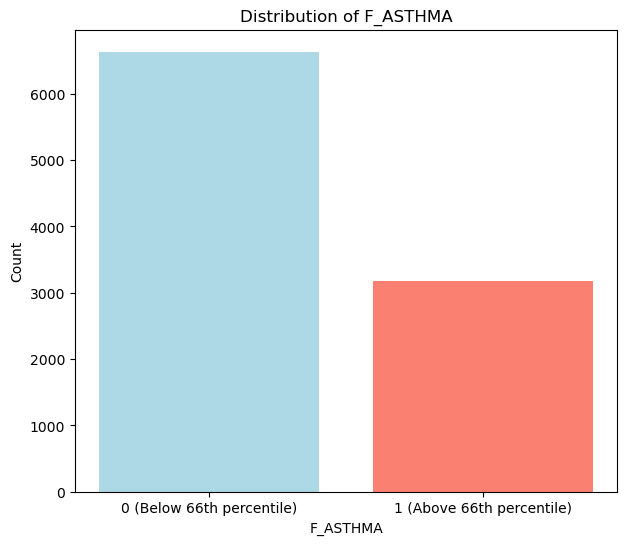

In [3]:
# Count the occurrences of each category in F_ASTHMA
counts = df['F_ASTHMA'].value_counts()
# Set up the figure and axes for the plot
fig, ax = plt.subplots(figsize=(7, 6))
ax.bar(counts.index, counts.values, color=['lightblue', 'salmon'])
ax.set_xlabel('F_ASTHMA')
ax.set_ylabel('Count')
ax.set_title('Distribution of F_ASTHMA')
ax.set_xticks([0, 1])
ax.set_xticklabels(['0 (Below 66th percentile)', '1 (Above 66th percentile)'])
plt.show()


<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

> **Q1:** Describe the class balance / imbalance. If there is an imbalance, how might it affect our classification algorithm? 

There is some class imbalance for asthma, where the tracts are classified as class 0 (below the 66th percentile) has around double the count compared to class 1 (above the 66th percentile). This means the model will train more on the 0 class, which can mislead accuracy based metrics and cause the model to favor the majority class, inserting some bias.

<!-- END QUESTION -->

---
## Step 2: Prepare Features for Modeling

Complete the following steps:

1. Create a dataframe called `df_model` that contains the following predictor variables: `EPL_POV200`, `EPL_UNEMP`, and `EPL_MINRTY`, and your response variable: `F_ASTHMA`.
2. Drop any rows in `df_model` with NAs. `KNeighborsClassifier` doesn't allow any NAs.
3. Create a variable `X` containing your predictors, and `y` containing your response variable.
4. Split into 70% train / 30% test using `train_test_split` with `stratify=y` and `random_state=42`. Store as `X_train`, `X_test`, `y_train`, `y_test`.

Because all three predictors are already percentile ranks on a 0–1 scale, features won't dominate KNN distances due to differing units, so no standardization step is needed.

In [4]:
# Prepare the data for modeling
df_model = df[['EPL_POV200', 'EPL_UNEMP', 'EPL_MINRTY', 'F_ASTHMA']].dropna()
X = df_model[['EPL_POV200', 'EPL_UNEMP', 'EPL_MINRTY']].values
y = df_model['F_ASTHMA']
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.3, stratify=y, random_state=42 )


print(f'Training set : {X_train.shape[0]:,} tracts')
print(f'Test set     : {X_test.shape[0]:,} tracts')

Training set : 6,813 tracts
Test set     : 2,920 tracts


In [5]:
grader.check("q3")

q3 results: All test cases passed!

---
## Step 3: Fit a K-Nearest Neighbors Classifier (k = 3)

As a starting point, fit a `KNeighborsClassifier` with `n_neighbors=3` on the training data. Store the fitted model in `knn3`, predictions on the test set in `y_pred_knn3`, and test-set accuracy in `knn3_accuracy`.

**sklearn workflow reminder:**
```python
model = SomeClassifier(...)        # 1. initialize
model.fit(X_train, y_train)        # 2. fit on training data
y_pred = model.predict(X_test)     # 3. predict on test data
acc = accuracy_score(y_test, y_pred)  # 4. evaluate
```
We'll use k = 3 here as a baseline, then use cross-validation in Step 4 to find the optimal k.

In [6]:
# Train KNN with K=3 and evaluate on the test set
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train, y_train)
y_pred_knn3   = knn3.predict(X_test)
knn3_accuracy = accuracy_score(y_test, y_pred_knn3)

print(f'KNN (K=3) test accuracy: {knn3_accuracy:.4f}')

KNN (K=3) test accuracy: 0.7418


In [7]:
grader.check("q4")

q4 results: All test cases passed!

---
## Step 4: Selecting K with 5-Fold Cross-Validation

Choosing K by checking accuracy on a single test split is risky because the result depends on which observations land in the test set. **Cross-validation** gives a more reliable estimate by rotating through multiple train splits on the training data, leaving the test set untouched.

Using `cross_val_score` with `cv=5`, compute the **mean** and **standard deviation** of the 5-fold cross-validation overall accuracy on the **training set** for each K from 1 to 20. Then:

1. Store the mean CV scores in `cv_mean_scores`. (a numpy array of length 20).
2. Plot mean CV accuracy.
3. Store the K with the **highest mean CV score** in `optimal_k` (smallest K in case of a tie) and that score in `best_cv_score`.

Once we have found the best value of K to use, we will run another KNN Model with the test data that hasn't been used to fit any model yet. 

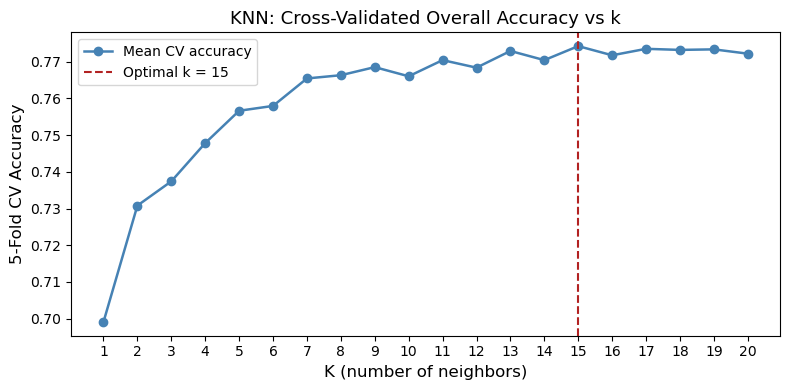

Optimal K = 15,  best mean CV accuracy = 0.7743


In [8]:
# k values from 1 to 20
k_values       = range(1, 21)
# Compute mean CV accuracy for each k
cv_mean_scores = np.array([cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train, y_train, cv=5).mean() for k in k_values])

# Find optimal k and corresponding best CV score
optimal_k     = np.argmax(cv_mean_scores) + 1 # + 1 since index starts at 0 and we want k starting at 1
best_cv_score = cv_mean_scores[np.argmax(cv_mean_scores)]

# Visualize optimal k
fig, ax = plt.subplots(figsize=(8, 4))  
ax.plot(k_values, cv_mean_scores, marker='o', color='steelblue', linewidth=1.8, label='Mean CV accuracy')  
ax.axvline(optimal_k, color='firebrick', linestyle='--', label=f'Optimal k = {optimal_k}')  
ax.set_xlabel('K (number of neighbors)', fontsize=12)  
ax.set_ylabel('5-Fold CV Accuracy', fontsize=12)  
ax.set_title('KNN: Cross-Validated Overall Accuracy vs k', fontsize=13) 
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))  
ax.legend()  
plt.tight_layout()  
plt.show()  

print(f'Optimal K = {optimal_k},  best mean CV accuracy = {best_cv_score:.4f}')

In [9]:
grader.check("q5")  

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q2:** Why is using cross-validation to select K better than using the single test-set accuracy from Step 3? What would you e

Cross-validation is better than using a single test-set accuracy because it splits the training data into five folds and averages accuracy across them, reducing the chance of selecting a K that is not truly representative. Additionally, if we used the test set to select K, we would be leaking information, meaning the reported accuracy would no longer be an honest estimate of how the model performs on new, unseen data.

<!-- END QUESTION -->

---
## Step 5: KNN with Optimal K
 Re- run your  K-Nearest Neighbors Classifier with number of neighbors equal to  `optimal_k`. Store your accuracy in `knn_optimal_accuracy`.



In [10]:
# Check optimal k accuracy on test set
knn_optimal_accuracy = KNeighborsClassifier(n_neighbors=optimal_k).fit(X_train, y_train).score(X_test, y_test)

print(f'KNN (K={optimal_k}) test accuracy: {knn_optimal_accuracy:.4f}')

KNN (K=15) test accuracy: 0.7760


In [11]:
grader.check("q7")

q7 results: All test cases passed!

In [12]:
# Added to create y_pred_knn_optimal for the autograder in q9
y_pred_knn_optimal = KNeighborsClassifier(n_neighbors=optimal_k).fit(X_train, y_train).predict(X_test)

<!-- BEGIN QUESTION -->

> **Q3:** Compare the test-set accuracy of `knn3` (K = 3) and `knn_optimal` (K = `optimal_k`). Which performed better, and by how much? Why might the optimal K found by cross-validation outperform the arbitrary choice of K = 3?


K = 3 has a test accuracy of 0.7418 while the optimal K = 15 has a test accuracy of 0.7760, performing better by 0.0342. This happens because the optimal K is found by cross-validation, which evaluates the model's performance on multiple subsets of the training data, allowing it to find a K that generalizes better to unseen data. In contrast, K = 3 is an arbitrary choice that may not be the best fit for the data, a very small K, like the arbitraty choice, makes the model more flexible and sensitive to noise in the training data, which can affect the performance on the test set.

<!-- END QUESTION -->

---
## Step 6: Logistic Regression with Cross-Validation


We will now create a Logistic Regression with the same predictors and outcome variable. 

1. Create a [`LogisticRegressionCV`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html) with `random_state=42` and `cv = 5`. Call it `lr`. The CV at the end of Logistic Regression is for cross fold validation. This allows you to use cross fold validation in your regression. 

>  Unlike plain [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression), LogisticRegressionCV automatically selects the best regularization strength C using 5-fold cross-validation. Regularization penalizes large coefficients to reduce overfitting; C controls how strong that penalty is. The cross-validation tries a range of C values and picks the one with the best average held-out accuracy across the 5 folds. 

2. Fit `lr` on the full training set, predict on the test set, and store predictions in `y_pred_lr` and test-set accuracy in `lr_accuracy`. This will be using the default threshold of $\alpha=0.5$.
3. Extract the coefficients from your linear regression with `.coef_[]` and `.intercept_[]`. Create a table with a feature and coefficient column to present your results. 

In [13]:
lr = LogisticRegressionCV(cv=5, random_state=42).fit(X_train, y_train)

y_pred_lr   = lr.predict(X_test)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_accuracy

0.7753424657534247

In [14]:
grader.check("q9")

q9 results: All test cases passed!

In [15]:
# Step 3: Extract the coefficients from the linear regression model
feature_names = ['EPL_POV200', 'EPL_UNEMP', 'EPL_MINRTY']

table = pd.DataFrame({
    'Feature': feature_names + ['Intercept'],
    'Coefficient': list(lr.coef_[0]) + [lr.intercept_[0]],
})
table

,Feature,Coefficient
0,EPL_POV200,5.008554
1,EPL_UNEMP,0.891915
2,EPL_MINRTY,-1.379598
3,Intercept,-3.320082


<!-- BEGIN QUESTION -->

> **Q4:** Which predictors have a negative association with a tract being flagged for high asthma prevalence? Interpret one of them in plain 
  language,
>
> **Note:** Notice this is an inference question. In this case we are using only a subset of the training data to answer it for convenience, but the best practice is to use *all the available data* to investigate inference questions and use a *training/test data* splot for prediction.

The predictor EPL_MINRTY has a negative association with a tract being flagged for high asthma prevalence. It means that as the percentage of minority population in a tract increases, the likelihood of that tract being flagged for high asthma prevalence decreases, holding other factors constant.

<!-- END QUESTION -->

---
## Step 7: Confusion Matrix for Logistic Regression

Compute the **confusion matrix** for the logistic regression predictions on the test set. Store the 2 x 2 numpy array in `cm_lr`. Plot it using `ConfusionMatrixDisplay` with display labels `['0', '1]'`.

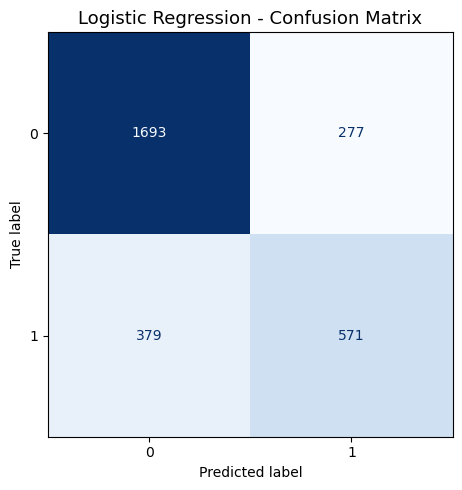

In [16]:
# Create a confusion matrix for the logistic regression
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Display the cm with labels and color
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                               display_labels=['0', '1'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression - Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()


In [17]:
grader.check("q11")

q11 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5:** Report the results of the confusion matrix. How many false positives, true positives, false negatives, and true negatives did your model predict? Interpret what each of those 4 results means in the context of the data.

The model predicted 571 true positives, 1693 true negatives, 379 false negatives, and 277 false positives. A true positive means the model correctly identified census tracts that truly have high asthma prevalence. A true negative means it correctly identified tracts that do not fall into the high‑asthma category. A false negative means the model predicted no high asthma prevalence for 379 tracts that actually do have elevated asthma rates, which represents the communities that are at high risk but were not identified. A false positive means the model predicted high asthma prevalence for 277 tracts that do not actually have high asthma risk, indicating that resources would be allocated to wrong tracts.

<!-- END QUESTION -->

---
## Step 8: Accuracy Metrics for Logistic Regression

 Calculate accuracy, precision, recall, and the F1 score. Store your results in `accuracy_lr`, `precision_lr`, `recall_lr`, and `f1_lr` with the functions from `sklearn.metrics`.

In [18]:
accuracy_lr  = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr    = recall_score(y_test, y_pred_lr)
f1_lr        = f1_score(y_test, y_pred_lr)


print(f'Accuracy  = {accuracy_lr:.4f}')
print(f'Precision = {precision_lr:.4f}')
print(f'Recall    = {recall_lr:.4f}')
print(f'F1 Score  = {f1_lr:.4f}')

Accuracy  = 0.7753
Precision = 0.6733
Recall    = 0.6011
F1 Score  = 0.6352


In [19]:
grader.check("q13")

q13 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q6:** Compare the accuracy, precision, recall, and F1 score for the logistic regression model. In the context of predicting high asthma risk tracts, which metric do you think is most important, and why? What is the trade-off between precision and recall here?

The model has an accuracy of 0.7753, but the precision (0.67) and recall (0.60) are noticeably lower, and the F1 score (0.64) being lower than the overall accuracy, suggests the model performs better on the majority class (low-risk tracts) than on the minority class (high-risk tracts). Recall can be considered the most important metric, mostly because we don't want to miss a tract that has a high risk of asthma, considering that the community needs intervention. The trade-off between precision and recall is that increasing recall means accepting lower precision and more false positives, meaning flagging tracts that aren't actually high risk.

<!-- END QUESTION -->

---
## Step 9: Confusion Matrix and Accuracy Metrics for KNN

Compute and plot the confusion matrix  for the **KNN (K = `optimal_k`)** model. Then calculate precision, recall, and F1 score. This lets you directly compare it to logistic regression beyond just overall accuracy.

KNN (k=15) Confusion Matrix:
[[1717  253]
 [ 401  549]]

Precision (KNN): 0.6845
Recall    (KNN): 0.5779
F1 Score  (KNN): 0.6267

--- Model Comparison ---
              KNN (k=15)    Logistic Reg
Accuracy:     0.7760         0.7753
F1 Score:     0.6267         0.6352


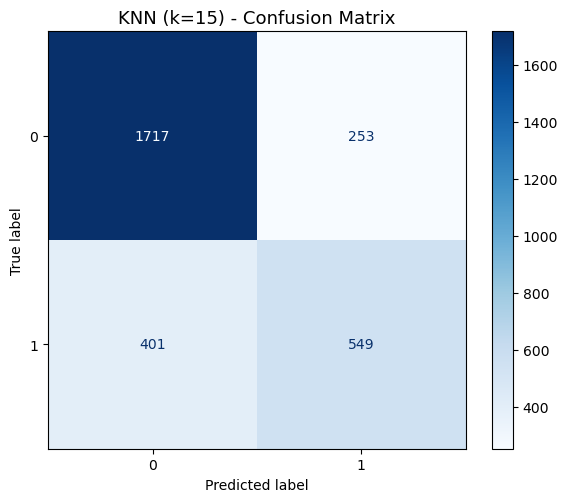

In [20]:
# Compute confusion matrix for KNN with optimal k
cm_knn = confusion_matrix(y_test, y_pred_knn_optimal)


precision_knn = precision_score(y_test, y_pred_knn_optimal)
recall_knn    = recall_score(y_test, y_pred_knn_optimal)
f1_knn        = f1_score(y_test, y_pred_knn_optimal)

print(f'KNN (k={optimal_k}) Confusion Matrix:\n{cm_knn}\n')
print(f'Precision (KNN): {precision_knn:.4f}')
print(f'Recall    (KNN): {recall_knn:.4f}')
print(f'F1 Score  (KNN): {f1_knn:.4f}')
print()
print('--- Model Comparison ---')
print(f'              KNN (k={optimal_k})    Logistic Reg')
print(f'Accuracy:     {knn_optimal_accuracy:.4f}         {lr_accuracy:.4f}')
print(f'F1 Score:     {f1_knn:.4f}         {f1_lr:.4f}')

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                              display_labels=['0', '1'])

# Plot confusion matrices for the KNN
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues')
ax.set_title('KNN (k=15) - Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
grader.check("q15")

q15 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q6:** Comment on the results of the Logistic Regression vs KNN. How do they compare in terms of performance? Which model would you pick? Why? 

The models perform very similarly in terms of accuracy (KNN: 0.7760, Logistic Regression: 0.7753). The most notable difference is in recall, where logistic regression (0.60) outperforms KNN (0.58), while KNN has slightly higher precision (0.68 vs 0.67). Logistic regression also has a slightly better F1 score (0.635 vs 0.627). Given the context of predicting high asthma risk tracts, I would pick logistic regression since it has higher recall, meaning fewer high-risk tracts are missed

<!-- END QUESTION -->

---
## Step 10: ROC Curve and AUC — Logistic Regression

The **Receiver Operating Characteristic (ROC)** curve plots the **True Positive Rate (Recall)** against the **False Positive Rate** across every possible classification threshold — not just the default 0.5 cutoff. This lets us see how the model trades off between catching more high-risk tracts (higher recall) and generating more false alarms (higher FPR).


Follow these steps:

1. **Get predicted probabilities.** Use `lr.predict_proba(X_test)` to get the predicted probability for each test observation. This returns a 2-column array — column 0 is the probability of class 0 (low asthma risk), column 1 is the probability of class 1 (high asthma risk). Keep only the class 1 probabilities and store in `y_proba_lr`.

2. **Compute the ROC curve.** Call `roc_curve(y_test, y_proba_lr)`. It returns three arrays: `fpr` (false positive rates), `tpr` (true positive rates), and `thresholds` — one entry per decision threshold the model evaluated.

3. **Compute AUC.** Pass `fpr` and `tpr` to `auc()` and store the result in `roc_auc`.

4. **Plot the ROC curve.** Create a line plot with `fpr` on the x-axis and `tpr` on the y-axis. Add a dashed diagonal line from (0, 0) to (1, 1) to represent a random classifier. Include axis labels, a title, and a legend that displays the AUC value.

In [22]:
y_proba_lr = lr.predict_proba(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr[:, 1])
roc_auc = auc(fpr, tpr)


print(f'Logistic Regression AUC: {roc_auc:.4f}')

Logistic Regression AUC: 0.8244


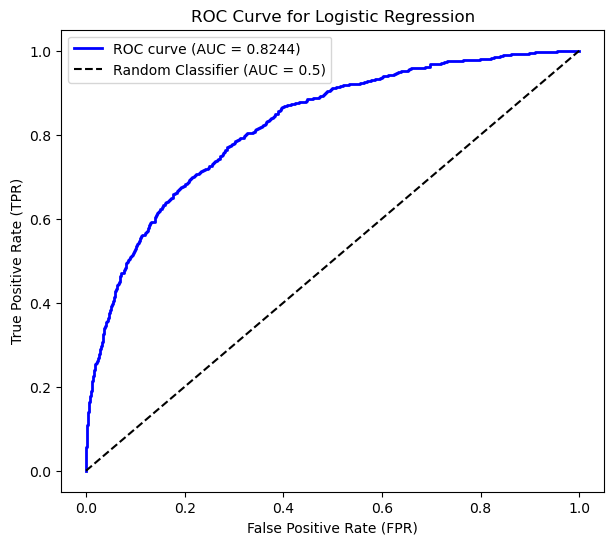

In [23]:
# Plot the ROC curve
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='blue', linewidth=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color="black", linestyle='--', label='Random Classifier (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve for Logistic Regression')
plt.legend()

In [24]:
grader.check("q17")

q17 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q7:** What does the AUC score tell you about the logistic regression model's ability to distinguish between high and low asthma risk tracts? Is this model meaningfully better than random guessing? How does the shape of the ROC curve reflect the precision-recall trade-off you observed in Step 8?

The AUC of around 0.82 tells us that the model can correctly distinguish between a high risk and low risk tract about 82% of the time across all possible thresholds, which is meaningfully better than random guessing, a random model would have an AUC of 0.5, meaning only a 50% chance of correctly classifying the right category. The shape of the ROC curve bends toward the top left corner, which reflects the precision-recall trade-off: as we increase the true positive rate (recall), more false positive observations start to appear. The closer to the top left, the better the model, because it balances the trade-off between TPR and FPR.

<!-- END QUESTION -->



---

**Run the cell below to receive credit for autograded questions**

In [25]:
grader.check_all()

q11 results: All test cases passed!

q13 results: All test cases passed!

q15 results: All test cases passed!

q17 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q7 results: All test cases passed!

q9 results: All test cases passed!